In [2]:
import sys
print(sys.executable)

/mnt/d/develop/mlops/ml/neural_network_deep_learning/.venv/bin/python


### 具体文档内容，查看alexey老师的github就行，老师最新2026年9月更新的课程记录md文件，
### 我觉得写的很好，不需要我重复记录笔记了
https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/main/10-kubernetes/01-overview.md
这个图很重要：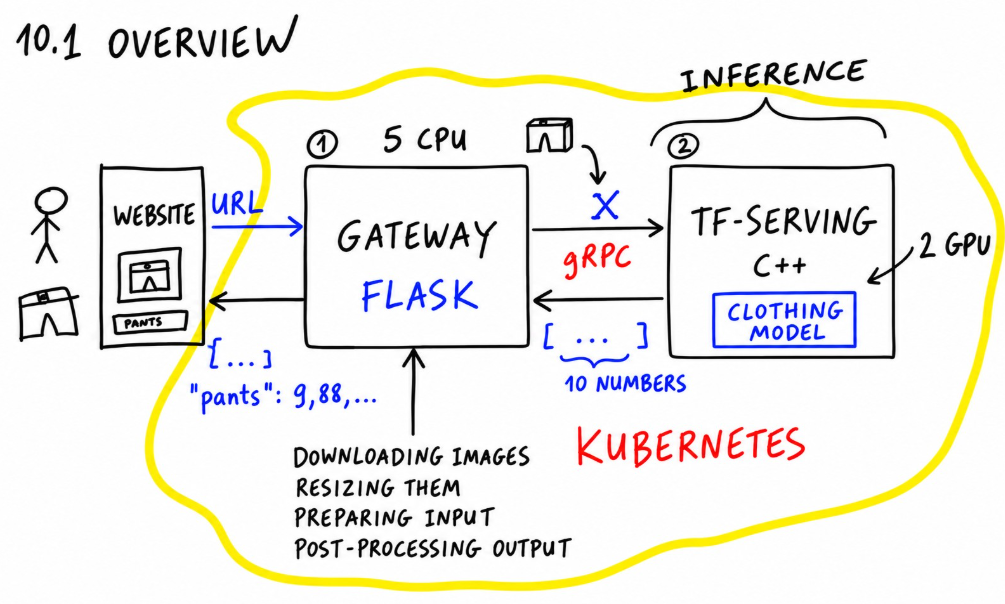

### Here is what we will do in this module:
- 将使用 Keras 训练的模型转换为 TensorFlow Serving 所期望的 SavedModel 格式（它与 TensorFlow 格式不同），然后用 Docker 部署本地，看看如何与它交互。
- 创建预处理服务——网关。
- 将每个服务放入自己的 Docker 容器，并使用 Docker Compose 来实现 在同一台机器上运行两个相互通信的服务。
- 谈谈Kubernetes的主要概念。
- 用 kind 本地运行 Kubernetes ——一个轻量级的 Kubernetes 在你的电脑上——然后部署一个简单的应用程序。
- 部署我们的两项服务到Kubernetes。
- 从本地的Kubernetes集群迁移到云端的集群。我们 将使用 AWS 提供的 Kubernetes 产品 EKS，但原则上是这样 应该能和任何云服务提供商合作。

# 将原始模型转换为SavedModel
- 原始模型就在09_neural_network_deep_learning目录中。- 名字叫做：xception_v4_1_20_0.864.h5 
- 我们把他放到新的目录11_k8s 中  ，改名为：clothing-model.h5

### 注意：本notebook的kernel 是mlops  TF2.13，就是 neural_network_deep_learning  虚拟机的tensorflwo的版本信息

In [ ]:
## 这就是 neural_network_deep_learning  虚拟机，完好状态下，依赖库的情况
(neural_network_deep_learning) (quant) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/ml/11_k8s# uv pip list | grep -E "tensorflow|tensorflow-serving-api|scipy|grpcio|keras-image-helper|numpy"
Using Python 3.11.15 environment at: /mnt/d/develop/mlops/ml/neural_network_deep_learning/.venv
grpcio                       1.74.0
keras-image-helper           0.0.2
numpy                        1.24.3
scipy                        1.13.1
tensorflow                   2.13.1
tensorflow-estimator         2.13.0
tensorflow-io-gcs-filesystem 0.37.1
tensorflow-serving-api       2.13.1

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import numpy as np
import tensorflow as tf
from tensorflow import keras


2026-09-16 11:46:20.888160: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-16 11:46:29.361997: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# 这会创建一个包含新模型的目录格式,加上一个带有权重的文件夹：

model = keras.models.load_model('clothing-model.h5')

# 先 predict 一次，强制所有变量初始化
_ = model.predict(np.zeros((1, 299, 299, 3), dtype=np.float32))

import shutil
shutil.rmtree('clothing-model', ignore_errors=True)

model.save('clothing-model')

2026-09-16 11:46:50.983465: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-16 11:46:51.487245: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-16 11:46:51.487300: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-16 11:46:51.489937: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-16 11:46:51.489986: I tensorflow/compile

1/1 [==============================] - 3s 3s/step
INFO:tensorflow:Assets written to: clothing-model/assets


INFO:tensorflow:Assets written to: clothing-model/assets


In [9]:
# 检查已保存模型内部的内容 
!saved_model_cli show --dir clothing-model --all

I0000 00:00:1789474898.521520  114713 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.

MetaGraphDef with tag-set: 'serve' contains the following SignatureDefs:

signature_def['__saved_model_init_op']:
  The given SavedModel SignatureDef contains the following input(s):
  The given SavedModel SignatureDef contains the following output(s):
    outputs['__saved_model_init_op'] tensor_info:
        dtype: DT_INVALID
        shape: unknown_rank
        name: NoOp
  Method name is: 

signature_def['serving_default']:
  The given SavedModel SignatureDef contains the following input(s):
    inputs['input_2'] tensor_info:
        dtype: DT_FLOAT
        shape: (-1, 299, 299, 3)
        name: serving_default_input_2:0
  The given SavedModel SignatureDef contains the following output(s):
   

In [ ]:
# 摘取其中的一段代码
signature_def['serving_default']:
  The given SavedModel SignatureDef contains the following input(s):
    inputs['input_2'] tensor_info:
        dtype: DT_FLOAT
        shape: (-1, 299, 299, 3)
        name: serving_default_input_2:0
  The given SavedModel SignatureDef contains the following output(s):
    outputs['dense_1'] tensor_info:
        dtype: DT_FLOAT
        shape: (-1, 10)
        name: StatefulPartitionedCall:0
  Method name is: tensorflow/serving/predict


### 这一段代码，是核心
### 可以理解为模型的“对外接口说明书”。它告诉调用方：这个模型接收什么、返回什么、怎么调用。
1. signature_def['serving_default']
- 这是签名的名称。一个 SavedModel 可以包含多个签名（signature），比如同时支持 serving_default（通用推理）、classify、regress 等。serving_default 是默认用于在线推理（serving）的那个，TensorFlow Serving 不加指定时就用它。
2. 输入部分（***inputs***）
- inputs：这是这个输入张量在签名里的逻辑名称。TensorFlow Serving 在 gRPC/REST 请求里用它来传数据（例如 REST 请求体里的 "inputs" 字段）。
- dtype: DT_FLOAT：数据类型是 32 位浮点数。
- shape: (-1, 299, 299, 3)：形状是一个四维张量，含义是：
- -1：batch 维度，表示一次可以传任意数量的样本（动态 batch）。
- 299, 299, 3：每张图片是 299×299 像素、3 个通道（RGB）。这正好是 Inception 系列网络的经典输入尺寸，所以这个模型很可能基于 InceptionV3/ResNet 之类的结构。
- name: serving_default_inputs:0：这是该张量在计算图里的真实节点名。通常你调用时用上面的 inputs 就够了，name 是底层图内部的标识。
3.  输出部分（***outputs***）
- outputs：输出张量在签名里的逻辑名称，返回结果时会以这个键给出。
- dtype: DT_FLOAT：输出也是 float。
- shape: (-1, 10)：每个样本输出 10 个浮点数。结合常见的分类任务，这几乎可以肯定是 10 分类问题（比如 MNIST 的 0–9，或 CIFAR-10 的十类）。这 10 个数通常是每个类别的 logits 或 softmax 概率，具体是哪种要看模型导出时的处理——output_0 这种命名常见于 Keras 模型导出，默认输出通常是 softmax 后的概率，但严谨起见要结合模型代码确认。（回顾课程，我们正是keras训练的模型，）
- name: StatefulPartitionedCall:0：底层图节点名。StatefulPartitionedCall 是 TF2 里函数被 traced 后常见的算子节点。
4. Method name is: tensorflow/serving/predict
这标明该签名对应的服务方法是 tensorflow/serving/predict，也就是标准的预测（Predict）API。TensorFlow Serving 会按这个方法来组织接口，客户端用 predict 请求即可。

### 把它拼成一个整体来看，这个模型对外提供的服务是：
- 输入：任意数量（N）的 299×299×3 的 RGB 浮点图像。
- 输出：每个图像对应的 10 维浮点向量（通常是 10 个类别的得分/概率）。
- 调用方式：TensorFlow Serving 的 predict 接口，请求/响应的键分别是 inputs 和 output_0。

In [5]:
# 使用该命令打印签名
!saved_model_cli show --dir clothing-model --tag_set serve --signature_def serving_default

I0000 00:00:1789370172.549728   31599 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
The given SavedModel SignatureDef contains the following input(s):
  inputs['inputs'] tensor_info:
      dtype: DT_FLOAT
      shape: (-1, 299, 299, 3)
      name: serving_default_inputs:0
The given SavedModel SignatureDef contains the following output(s):
  outputs['output_0'] tensor_info:
      dtype: DT_FLOAT
      shape: (-1, 10)
      name: StatefulPartitionedCall:0
Method name is: tensorflow/serving/predict


# 使用 Docker 运行 TensorFlow 服务

In [ ]:
# clothing-model模型，是拿tensorflow 2.13.1
docker pull docker.m.daocloud.io/tensorflow/serving:2.13.1

In [ ]:
# 默认映射的RPC端口8500，同时会启动8501的REST端口，自动加载了模型，  1 表示这个模型的第 1 版。一定要在11_8ks中运行，因为挂在路径写死了
docker run -it --rm \
  -p 8500:8500 \
  -v $(pwd)/clothing-model:/models/clothing-model/1 \
  -e MODEL_NAME="clothing-model" \
  docker.m.daocloud.io/tensorflow/serving:2.13.1

In [ ]:
# 装两个包，keras-image-helper 这个我的quant虚拟机中已经有了，安装前最好检查一下
#pip install grpcio==1.62.0 tensorflow-serving-api==2.20.0
#pip install keras-image-helper 

## 然后导入所需信息，并创建一个gRPC通道到服务器：11_k8s 目录中创建
- vi tf-serving-connect.py
- 我们使用不安全的channel，因为我们是在本地尝试——一个安全的 我们会在channel上添加认证。
- 我们这里不需要这个： 整个系统最终都会运行在 Kubernetes 内部，同时也是网关 以及TensorFlow Serving，而TensorFlow Seriving将无法访问 从外部看。
- 存根是我们用来调用远程服务的东西——我们将用它来做预测。

In [3]:
import grpc

import tensorflow as tf

from tensorflow_serving.apis import predict_pb2  # 用来构造发给 Serving 的预测请求
from tensorflow_serving.apis import prediction_service_pb2_grpc
# 是 protobuf 编译器根据 .proto 文件自动生成的 gRPC 代码。
#里面包含：PredictionServiceStub ← 客户端用的（你要用的），PredictionServiceServicer ← 服务端实现的基类（Serving 内部用，你不用管），add_PredictionServiceServicer_to_server() ← 服务端注册函数
from keras_image_helper import create_preprocessor  #图像预处理器
host = 'localhost:8500'

channel = grpc.insecure_channel(host) #创建通道

stub = prediction_service_pb2_grpc.PredictionServiceStub(channel)   
#stub本地的一个代理对象。调它的方法，它帮你把参数序列化、发到远端、收响应、反序列化，全程你不用碰 socket 和协议细节。


###  图像预处理，下载了图片，将其大小调整为299乘299，并应用Xception预处理：keras-image-helper
- protobuf（Protocol Buffers） 是 Google 开发的一种数据序列化格式，你可以把它理解成一种比 JSON/XML 更小、更快、更严格的“数据打包方式”。
- gRPC 默认就是用 protobuf 作为它的数据格式，两者是天然绑定的一对。

In [4]:
preprocessor = create_preprocessor('xception', target_size=(299, 299)) 
preprocessor

In [5]:
url = 'https://pic.mksucai.com/00/10/42/60e8c5905c7695a3.webp'
X = preprocessor.from_url(url)

In [6]:
# 定义转换函数：将numpy数组转换为protobuf
def np_to_protobuf(data):
    return tf.make_tensor_proto(data, shape=data.shape)

### 准备请求。告诉它使用哪个模型（），使用哪个签名（），并将我们的protobuf张量放在签名中看到的输入名称下
- clothing-model  serving_default  input_8

In [9]:
pb_request = predict_pb2.PredictRequest()

pb_request.model_spec.name = 'clothing-model'
pb_request.model_spec.signature_name = 'serving_default'

pb_request.inputs['input_2'].CopyFrom(np_to_protobuf(X))

In [10]:
pb_response = stub.Predict(pb_request, timeout=20.0)
pb_response

model_spec {
  name: "clothing-model"
  version {
    value: 1
  }
  signature_name: "serving_default"
}
outputs {
  key: "dense_1"
  value {
    dtype: DT_FLOAT
    tensor_shape {
      dim {
        size: 1
      }
      dim {
        size: 10
      }
    }
    float_val: -2.1015234
    float_val: -5.53523731
    float_val: -2.53121233
    float_val: -1.95719898
    float_val: 9.97263908
    float_val: -1.39643931
    float_val: -2.5511272
    float_val: -0.281225175
    float_val: -3.94673634
    float_val: -3.62423921
  }
}

In [15]:
preds = pb_response.outputs['dense_1'].float_val

In [16]:
classes = [
    'dress',
    'hat',
    'longsleeve',
    'outwear',
    'pants',
    'shirt',
    'shoes',
    'shorts',
    'skirt',
    't-shirt'
]

In [17]:
dict(zip(classes, preds))

{'dress': -2.1015233993530273,
 'hat': -5.5352373123168945,
 'longsleeve': -2.531212329864502,
 'outwear': -1.957198977470398,
 'pants': 9.972639083862305,
 'shirt': -1.3964393138885498,
 'shoes': -2.5511271953582764,
 'shorts': -0.28122517466545105,
 'skirt': -3.9467363357543945,
 't-shirt': -3.624239206314087}

#  结果显示然是 裤子